In [1]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr
import xarray as xr

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *

In [2]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
lat_dim, lon_dim, ddof = "lat", "lon", 1

# Fix one area measure for all models/members. Zero or invalid weights exclude cells.
# If weights have coordinate labels, check them against each model grid below.
weights_input = ERA5["weights"]
if isinstance(weights_input, xr.DataArray):
    weights_input = weights_input.transpose(lat_dim, lon_dim)
weights = np.asarray(weights_input, dtype=float)
support = np.isfinite(weights) & (weights > 0)
if not support.any():
    raise ValueError("No positive finite area weights remain.")
area_weights = np.where(support, weights, 0.)
area_weights = area_weights / area_weights.sum()
weights_1D   = np.array(area_weights).reshape(n_flat)



amip_hist_models        = np.load('./data/helper/amip_hist_models.npy')
amip_piForcing_models   = np.load('./data/helper/amip_piForcing_models.npy')
historical_models       = np.load('./data/helper/historical_models.npy')

amip_hist_n_ensembles       = np.load('./data/helper/amip_hist_n_ensembles.npy')
amip_piForcing_n_ensembles  = np.load('./data/helper/amip_piForcing_n_ensembles.npy')
historical_n_ensembles      = np.load('./data/helper/historical_n_ensembles.npy')

print("amip_hist_models =", amip_hist_models)
print("amip_piForcing_models =", amip_piForcing_models)
print("historical_models =", historical_models)

print("amip_hist_n_ensembles =", amip_hist_n_ensembles)
print("amip_piForcing_n_ensembles =", amip_piForcing_n_ensembles)
print("historical_n_ensembles =", historical_n_ensembles)

n_amip_hist         = len(amip_hist_models)
n_amip_piForcing    = len(amip_piForcing_models)
n_historical        = len(historical_models)

print(n_time,n_lat,n_lon,n_flat)
print(area_weights.shape)
print(area_weights.sum())

amip_hist_models = ['BCC-CSM2-MR' 'CAMS-CSM1-0' 'CESM2' 'CIESM' 'CNRM-CM6-1' 'CNRM-CM6-1-HR'
 'CNRM-ESM2-1' 'CanESM5' 'FGOALS-f3-L' 'FGOALS-g3' 'FIO-ESM-2-0'
 'IITM-ESM' 'IPSL-CM6A-LR' 'MIROC6' 'MRI-ESM2-0' 'TaiESM1']
amip_piForcing_models = ['CESM2' 'CNRM-CM6-1' 'CanESM5' 'HadGEM3-GC31-LL' 'IPSL-CM6A-LR' 'MIROC6'
 'MRI-ESM2-0' 'TaiESM1']
historical_models = ['ACCESS-CM2' 'ACCESS-ESM1-5' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR'
 'BCC-CSM2-MR' 'BCC-ESM1' 'CAMS-CSM1-0' 'CAS-ESM2-0' 'CESM2' 'CESM2-FV2'
 'CESM2-WACCM' 'CESM2-WACCM-FV2' 'CIESM' 'CMCC-CM2-HR4' 'CMCC-CM2-SR5'
 'CMCC-ESM2' 'CNRM-CM6-1' 'CNRM-CM6-1-HR' 'CNRM-ESM2-1' 'CanESM5'
 'CanESM5-CanOE' 'E3SM-1-0' 'E3SM-1-1' 'E3SM-1-1-ECA' 'EC-Earth3'
 'EC-Earth3-AerChem' 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR' 'FGOALS-f3-L'
 'FGOALS-g3' 'FIO-ESM-2-0' 'GISS-E2-1-G' 'GISS-E2-1-G-CC' 'GISS-E2-1-H'
 'IITM-ESM' 'INM-CM4-8' 'INM-CM5-0' 'IPSL-CM5A2-INCA' 'IPSL-CM6A-LR'
 'IPSL-CM6A-LR-INCA' 'KACE-1-0-G' 'KIOST-ESM' 'MIROC6' 'MPI-ESM-1-2-HAM'
 'MPI-ESM1-2-HR'

In [3]:
covRTi_amip_hist            = np.load("./data/maps_2000_2014_covImp/covRTi_amip_hist.npy",allow_pickle=True).item()
covTRi_amip_hist            = np.load("./data/maps_2000_2014_covImp/covTRi_amip_hist.npy",allow_pickle=True).item()
regTiRi_amip_hist           = np.load("./data/maps_2000_2014_covImp/regTiRi_amip_hist.npy",allow_pickle=True).item()
remote_Ti_Rjsum_amip_hist   = np.load("./data/maps_2000_2014_covImp/remote_Ti_Rjsum_amip_hist.npy",allow_pickle=True).item()
local_Ti_Ri_amip_hist       = np.load("./data/maps_2000_2014_covImp/local_Ti_Ri_amip_hist.npy",allow_pickle=True).item()

covRTi_historical            = np.load("./data/maps_2000_2014_covImp/covRTi_historical.npy",allow_pickle=True).item()
covTRi_historical            = np.load("./data/maps_2000_2014_covImp/covTRi_historical.npy",allow_pickle=True).item()
regTiRi_historical           = np.load("./data/maps_2000_2014_covImp/regTiRi_historical.npy",allow_pickle=True).item()
remote_Ti_Rjsum_historical   = np.load("./data/maps_2000_2014_covImp/remote_Ti_Rjsum_historical.npy",allow_pickle=True).item()
local_Ti_Ri_historical       = np.load("./data/maps_2000_2014_covImp/local_Ti_Ri_historical.npy",allow_pickle=True).item()

model_mean_maps     = np.load("./data/maps_2000_2014_covImp/model_mean_maps.npy",allow_pickle=True).item()
MMM_maps            = np.load("./data/maps_2000_2014_covImp/MMM_maps.npy",allow_pickle=True).item()
MMM_stats           = np.load("./data/maps_2000_2014_covImp/MMM_stats.npy",allow_pickle=True).item()
MMM_model_names     = np.load("./data/maps_2000_2014_covImp/MMM_model_names.npy",allow_pickle=True).item()

covRTi_obs          = np.load("./data/maps_2000_2014_covImp/covRTi_obs.npy",allow_pickle=True)
covTRi_obs          = np.load("./data/maps_2000_2014_covImp/covTRi_obs.npy",allow_pickle=True)
regTiRi_obs         = np.load("./data/maps_2000_2014_covImp/regTiRi_obs.npy",allow_pickle=True)
local_Ti_Ri_obs     = np.load("./data/maps_2000_2014_covImp/local_Ti_Ri_obs.npy",allow_pickle=True)
remote_Ti_Rjsum_obs = np.load("./data/maps_2000_2014_covImp/remote_Ti_Rjsum_obs.npy",allow_pickle=True)

observed_maps = {
    "covRTi": covRTi_obs, "covTRi": covTRi_obs, "regTiRi": regTiRi_obs,
    "local_Ti_Ri": local_Ti_Ri_obs, "remote_Ti_Rjsum": remote_Ti_Rjsum_obs,
}
member_maps = {
    "amip_hist": {
        "covRTi": covRTi_amip_hist, "covTRi": covTRi_amip_hist,
        "regTiRi": regTiRi_amip_hist, "local_Ti_Ri": local_Ti_Ri_amip_hist,
        "remote_Ti_Rjsum": remote_Ti_Rjsum_amip_hist,
    },
    "historical": {
        "covRTi": covRTi_historical, "covTRi": covTRi_historical,
        "regTiRi": regTiRi_historical, "local_Ti_Ri": local_Ti_Ri_historical,
        "remote_Ti_Rjsum": remote_Ti_Rjsum_historical,
    },
}

# Matched historical shares the original member data, but uses its own saved
# model list, ensemble-mean stack, and MMM. No member maps are copied here.
member_maps["historical_matched"] = member_maps["historical"]
score_experiments = ["amip_hist", "historical", "historical_matched"]
score_model_names = {exp: list(MMM_model_names[exp]) for exp in score_experiments}

shared_model_set = set(score_model_names["amip_hist"]) & set(score_model_names["historical"])
if set(score_model_names["historical_matched"]) != shared_model_set or not shared_model_set:
    raise ValueError("Rebuild historical_matched: its model list must equal the nonempty shared set.")

In [4]:
# %% Compare members, ensemble-mean maps, and MMM maps against observations
# Run after loading your saved structures and defining compare_maps.
import numpy as np

# Observations are always x (reference); model maps are always y (comparison).

# None uses pairwise finite-data masking. For strictly common spatial support,
# supply a boolean mask containing only cells valid across all comparisons.
# Do not use model-specific significance masks to define the comparison domain.
comparison_mask = None
comparison_weights = area_weights

# Keep mean member performance separate from performance of the averaged map.
# The first three outputs use [experiment][metric][model][score].
# MMM_scores uses [experiment][metric][score].
member_scores, mean_member_scores, model_mean_scores, MMM_scores = {}, {}, {}, {}

for experiment in score_experiments:
    models = score_model_names[experiment]
    if not models or len(models) != len(set(models)):
        raise ValueError(f"{experiment}: model names must be nonempty and unique.")

    for output in [member_scores, mean_member_scores, model_mean_scores, MMM_scores]:
        output[experiment] = {}

    for metric, observation in observed_maps.items():
        # Saved names determine the model axis of the saved ensemble-mean maps.
        # These shape checks do not replace geographic alignment beforehand.
        observation = np.ma.asarray(observation, dtype=float).filled(np.nan)
        means = np.ma.asarray(model_mean_maps[experiment][metric], dtype=float).filled(np.nan)
        if means.shape != (len(models), *observation.shape):
            raise ValueError(f"{experiment}/{metric}: model-mean shape does not match names/observations.")

        for output in [member_scores, mean_member_scores, model_mean_scores]:
            output[experiment][metric] = {}

        for m, model in enumerate(models):
            members = np.ma.asarray(member_maps[experiment][metric][model], dtype=float).filled(np.nan)
            if members.ndim != observation.ndim + 1 or members.shape[1:] != observation.shape or members.shape[0] == 0:
                raise ValueError(f"{experiment}/{metric}/{model}: expected (member, *observation.shape).")

            # Calculate each member's scores independently, retaining saved member order.
            # The stored array determines the member count, not the helper count arrays.
            print(f"{experiment} / {metric} / {model}: {len(members)} members")
            per_member = []
            for e, member_map in enumerate(members):
                result = compare_maps(observation, member_map, weights=comparison_weights, mask=comparison_mask)
                per_member.append(result)

            # Store an array per score, including all normalized errors, CCC,
            # and coverage metadata. Each array has shape (number_of_members,).
            arrays = {key: np.asarray([result[key] for result in per_member]) for key in per_member[0]}
            member_scores[experiment][metric][model] = arrays

            # Average each score across members where that score is finite.
            # All-undefined scores stay NaN. Metadata are averaged too:
            # n_valid here becomes the average number of scored spatial cells.
            averages = {}
            for key, values in arrays.items():
                finite = np.isfinite(values)
                averages[key] = float(values[finite].mean()) if finite.any() else np.nan
            mean_member_scores[experiment][metric][model] = averages

            # Separately score the saved ensemble-mean MAP against observations.
            # This need not equal the average member score calculated above.
            model_mean_scores[experiment][metric][model] = compare_maps(
                observation, means[m], weights=comparison_weights, mask=comparison_mask
            )

        # Score this experiment's saved MMM once per diagnostic.
        # historical_matched uses its own MMM, not the all-historical MMM.
        MMM_scores[experiment][metric] = compare_maps(
            observation, MMM_maps[experiment][metric],
            weights=comparison_weights, mask=comparison_mask
        )

amip_hist / covRTi / BCC-CSM2-MR: 1 members
amip_hist / covRTi / CAMS-CSM1-0: 3 members
amip_hist / covRTi / CESM2: 3 members
amip_hist / covRTi / CIESM: 3 members
amip_hist / covRTi / CNRM-CM6-1: 10 members
amip_hist / covRTi / CNRM-CM6-1-HR: 1 members
amip_hist / covRTi / CNRM-ESM2-1: 1 members
amip_hist / covRTi / CanESM5: 10 members
amip_hist / covRTi / FGOALS-f3-L: 3 members
amip_hist / covRTi / FGOALS-g3: 4 members
amip_hist / covRTi / FIO-ESM-2-0: 3 members
amip_hist / covRTi / IITM-ESM: 1 members
amip_hist / covRTi / IPSL-CM6A-LR: 3 members
amip_hist / covRTi / MIROC6: 5 members
amip_hist / covRTi / MRI-ESM2-0: 5 members
amip_hist / covRTi / TaiESM1: 3 members
amip_hist / covTRi / BCC-CSM2-MR: 1 members
amip_hist / covTRi / CAMS-CSM1-0: 3 members
amip_hist / covTRi / CESM2: 3 members
amip_hist / covTRi / CIESM: 3 members
amip_hist / covTRi / CNRM-CM6-1: 10 members
amip_hist / covTRi / CNRM-CM6-1-HR: 1 members
amip_hist / covTRi / CNRM-ESM2-1: 1 members
amip_hist / covTRi / CanE

In [5]:
# # kill
save_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs")
# save_dir.mkdir(parents=True, exist_ok=True)

# # Each file preserves the nested dictionaries, including historical_matched.
# outputs = {
#     "member_scores": member_scores, "mean_member_scores": mean_member_scores,
#     "model_mean_scores": model_mean_scores, "MMM_scores": MMM_scores,
#     "score_model_names": score_model_names,
# }
# for name, data in outputs.items():
#     np.save(save_dir / f"{name}.npy", data, allow_pickle=True)

save_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs")
member_scores      = np.load(save_dir / "member_scores.npy", allow_pickle=True).item()
mean_member_scores = np.load(save_dir / "mean_member_scores.npy", allow_pickle=True).item()
model_mean_scores  = np.load(save_dir / "model_mean_scores.npy", allow_pickle=True).item()
MMM_scores         = np.load(save_dir / "MMM_scores.npy", allow_pickle=True).item()
score_model_names  = np.load(save_dir / "score_model_names.npy", allow_pickle=True).item()

In [6]:
# Pool member RMSEs across all models for one experiment and diagnostic.

all_member_rmse_historical_matched_covRTi = np.concatenate([
    member_scores["historical_matched"]["covRTi"][model]["rmse"]
    for model in score_model_names[experiment]
])
all_member_rmse_amip_hist_covRTi = np.concatenate([
    member_scores["amip_hist"]["covRTi"][model]["rmse"]
    for model in score_model_names[experiment]
])

(array([[ 0., 32., 63., 24., 12.,  4.,  3.,  1.,  2.,  1.],
        [22., 23., 10.,  1.,  2.,  0.,  0.,  1.,  0.,  0.]]),
 array([0.05877733, 0.07135906, 0.08394079, 0.09652251, 0.10910424,
        0.12168597, 0.1342677 , 0.14684943, 0.15943115, 0.17201288,
        0.18459461]),
 <a list of 2 BarContainer objects>)

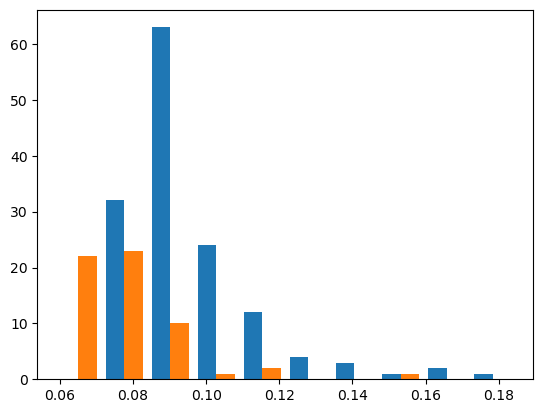

In [7]:
plt.hist((all_member_rmse_historical_matched_covRTi, all_member_rmse_amip_hist_covRTi))

/scratch/leiff/scratch_xcenv2/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 11.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


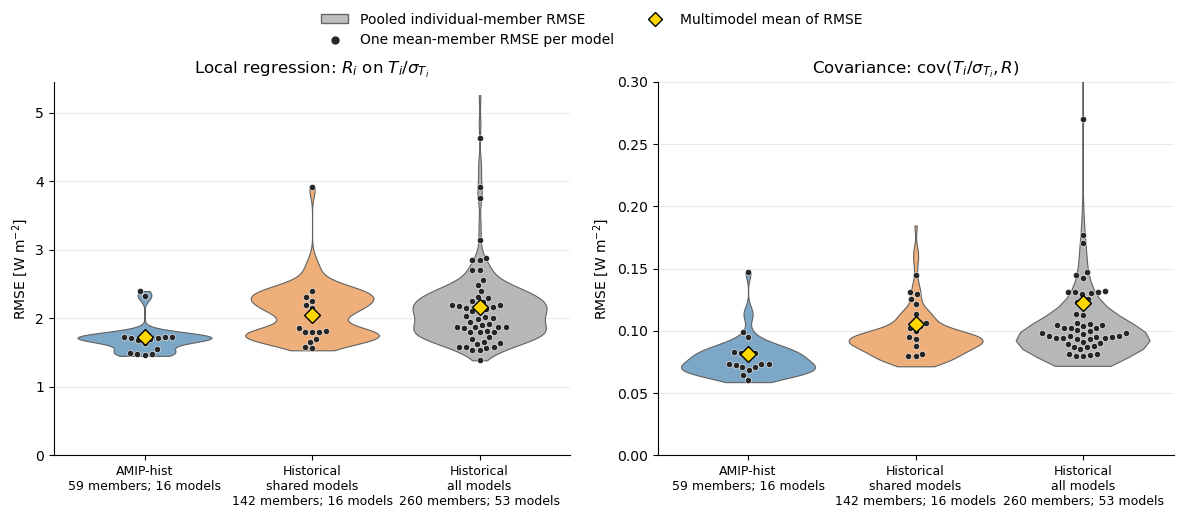

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                       # Requires seaborn >= 0.13
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Plot each member's RMSE, then overlay the average of those RMSEs for each model.
# This is NOT the RMSE of the ensemble-mean map.
plot_metrics = ["regTiRi", "covRTi"]
experiment_order = ["amip_hist", "historical_matched", "historical"]
experiment_labels = ["AMIP-hist", "Historical\nshared models", "Historical\nall models"]
colors = dict(zip(experiment_order, ["#74A9CF", "#FDAE6B", "#B7B7B7"]))
titles = [r"Local regression: $R_i$ on $T_i/\sigma_{T_i}$",
          r"Covariance: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$"]

# Convert the nested dictionaries into labeled tables, keeping model/member
# identities available for inspection. Exclude undefined scores from the plots.
member_rows, model_rows = [], []
for experiment in experiment_order:
    for metric in plot_metrics:
        for model, scores in member_scores[experiment][metric].items():
            for member, value in enumerate(scores["rmse"]):
                if np.isfinite(value):
                    member_rows.append((experiment, metric, model, member, value))
            value = mean_member_scores[experiment][metric][model]["rmse"]
            if np.isfinite(value):
                model_rows.append((experiment, metric, model, value))

violin_members = pd.DataFrame(member_rows, columns=["experiment", "metric", "model", "member", "value"])
violin_model_means = pd.DataFrame(model_rows, columns=["experiment", "metric", "model", "value"])

# Separate panel scales accommodate the different diagnostic magnitudes.
# Equal maximum violin widths emphasize shape; counts are shown beneath each.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, metric, title in zip(axes, plot_metrics, titles):
    members = violin_members[violin_members["metric"] == metric]
    means = violin_model_means[violin_model_means["metric"] == metric]

    # cut=0 limits the density to the observed range. bw_adjust controls smoothing.
    # Members are pooled without model reweighting, as intended for these violins.
    sns.violinplot(data=members, x="experiment", y="value", hue="experiment",
                   order=experiment_order, hue_order=experiment_order, palette=colors,
                   dodge=False, legend=False, inner=None, cut=0, density_norm="width",
                   bw_adjust=0.8, linewidth=0.8, saturation=0.8, ax=ax)

    # Each point represents one model. Beeswarm placement changes only horizontal
    # position, so its vertical position remains the model's mean member RMSE.
    sns.swarmplot(data=means, x="experiment", y="value", order=experiment_order,
                  color="0.15", size=4.5, edgecolor="white", linewidth=0.4, zorder=3, ax=ax)

    # Diamond: average of member/model RMSEs.
    ax.scatter(range(len(experiment_order)),
           [means.loc[means["experiment"] == exp, "value"].mean() for exp in experiment_order],
           marker="D", s=65, color="gold", edgecolor="black", zorder=5)

    # Report finite plotted counts rather than assuming a fixed ensemble size.
    tick_labels = []
    for experiment, label in zip(experiment_order, experiment_labels):
        n_members = (members["experiment"] == experiment).sum()
        n_models = (means["experiment"] == experiment).sum()
        tick_labels.append(f"{label}\n{n_members} members; {n_models} models")

    ax.set_xticks(range(len(experiment_order)))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set(title=title, xlabel="", ylabel=r"RMSE [W m$^{-2}$]", ylim=(0, None))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.6)
    sns.despine(ax=ax)

## Leif mods
axes[1].set_ylim([0,0.3])

# One legend explains the two sampling levels across both panels.
handles = [Patch(facecolor="0.75", edgecolor="0.4", label="Pooled individual-member RMSE"),
           Line2D([], [], marker="o", linestyle="none", color="0.15", markersize=5,
                  label="One mean-member RMSE per model")]
handles.append(Line2D([], [], marker="D", linestyle="none", color="gold", markeredgecolor="black", markersize=7, label="Multimodel mean of RMSE"))
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig("./data/maps_2000_2014_covImp/Fig_1/member_rmse_violins.png", dpi=300, bbox_inches="tight")
plt.show()

/scratch/leiff/scratch_xcenv2/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 11.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


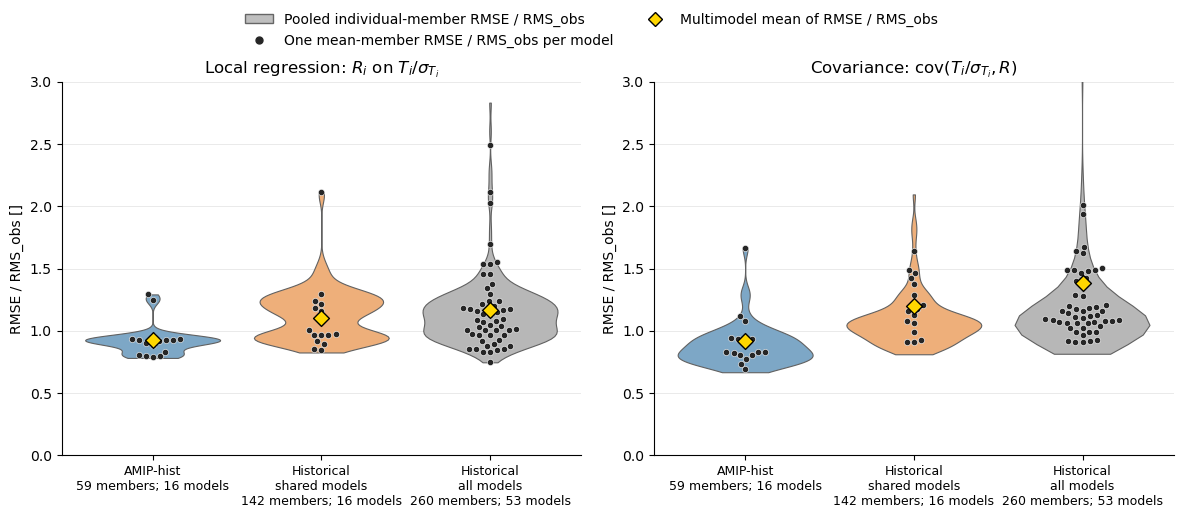

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                       # Requires seaborn >= 0.13
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Plot each member's RMSE, then overlay the average of those RMSEs for each model.
# This is NOT the RMSE of the ensemble-mean map.
plot_metrics = ["regTiRi", "covRTi"]
experiment_order = ["amip_hist", "historical_matched", "historical"]
experiment_labels = ["AMIP-hist", "Historical\nshared models", "Historical\nall models"]
colors = dict(zip(experiment_order, ["#74A9CF", "#FDAE6B", "#B7B7B7"]))
titles = [r"Local regression: $R_i$ on $T_i/\sigma_{T_i}$",
          r"Covariance: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$"]

# Convert the nested dictionaries into labeled tables, keeping model/member
# identities available for inspection. Exclude undefined scores from the plots.
member_rows, model_rows = [], []
for experiment in experiment_order:
    for metric in plot_metrics:
        for model, scores in member_scores[experiment][metric].items():
            for member, value in enumerate(scores["rmse_over_rms_x"]):
                if np.isfinite(value):
                    member_rows.append((experiment, metric, model, member, value))
            value = mean_member_scores[experiment][metric][model]["rmse_over_rms_x"]
            if np.isfinite(value):
                model_rows.append((experiment, metric, model, value))

violin_members = pd.DataFrame(member_rows, columns=["experiment", "metric", "model", "member", "value"])
violin_model_means = pd.DataFrame(model_rows, columns=["experiment", "metric", "model", "value"])

# Separate panel scales accommodate the different diagnostic magnitudes.
# Equal maximum violin widths emphasize shape; counts are shown beneath each.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, metric, title in zip(axes, plot_metrics, titles):
    members = violin_members[violin_members["metric"] == metric]
    means = violin_model_means[violin_model_means["metric"] == metric]

    # cut=0 limits the density to the observed range. bw_adjust controls smoothing.
    # Members are pooled without model reweighting, as intended for these violins.
    sns.violinplot(data=members, x="experiment", y="value", hue="experiment",
                   order=experiment_order, hue_order=experiment_order, palette=colors,
                   dodge=False, legend=False, inner=None, cut=0, density_norm="width",
                   bw_adjust=0.8, linewidth=0.8, saturation=0.8, ax=ax)

    # Each point represents one model. Beeswarm placement changes only horizontal
    # position, so its vertical position remains the model's mean member RMSE.
    sns.swarmplot(data=means, x="experiment", y="value", order=experiment_order,
                  color="0.15", size=4.5, edgecolor="white", linewidth=0.4, zorder=3, ax=ax)

    # Diamond: average of member/model RMSEs.
    ax.scatter(range(len(experiment_order)),
           [means.loc[means["experiment"] == exp, "value"].mean() for exp in experiment_order],
           marker="D", s=65, color="gold", edgecolor="black", zorder=5)

    # Report finite plotted counts rather than assuming a fixed ensemble size.
    tick_labels = []
    for experiment, label in zip(experiment_order, experiment_labels):
        n_members = (members["experiment"] == experiment).sum()
        n_models = (means["experiment"] == experiment).sum()
        tick_labels.append(f"{label}\n{n_members} members; {n_models} models")

    ax.set_xticks(range(len(experiment_order)))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set(title=title, xlabel="", ylabel=r"RMSE / RMS_obs []", ylim=(0, None))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.6)
    sns.despine(ax=ax)
    ax.set_ylim([0,3])

# One legend explains the two sampling levels across both panels.
handles = [Patch(facecolor="0.75", edgecolor="0.4", label="Pooled individual-member RMSE / RMS_obs"),
           Line2D([], [], marker="o", linestyle="none", color="0.15", markersize=5,
                  label="One mean-member RMSE / RMS_obs per model")]
handles.append(Line2D([], [], marker="D", linestyle="none", color="gold", markeredgecolor="black", markersize=7, label="Multimodel mean of RMSE / RMS_obs"))
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)

fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig("./data/maps_2000_2014_covImp/Fig_1/member_rmse_over_rms_x_violins.png", dpi=300, bbox_inches="tight")
plt.show()

/scratch/leiff/scratch_xcenv2/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 11.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


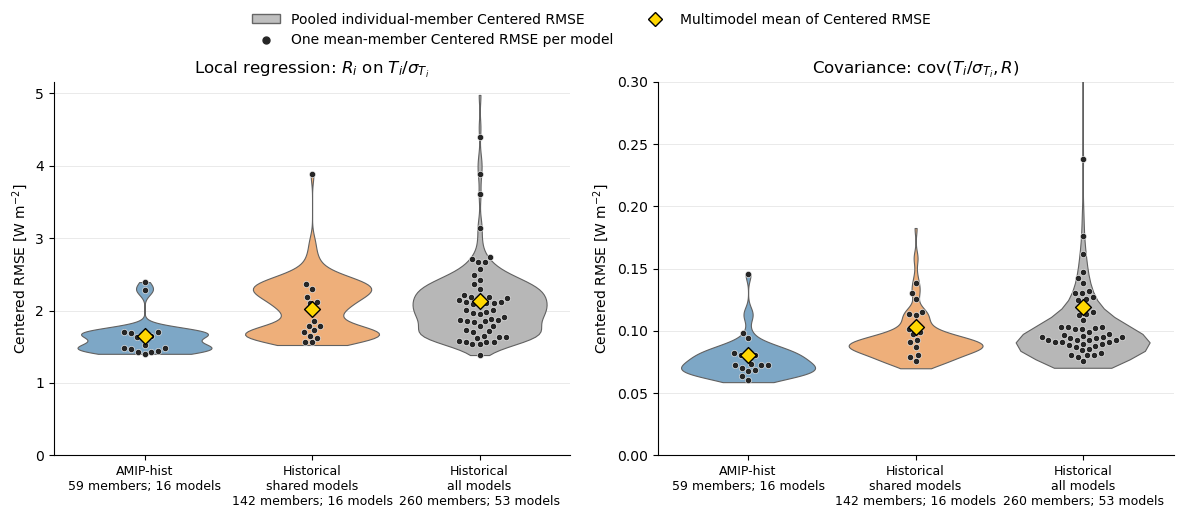

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                       # Requires seaborn >= 0.13
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Plot each member's RMSE, then overlay the average of those RMSEs for each model.
# This is NOT the RMSE of the ensemble-mean map.
plot_metrics = ["regTiRi", "covRTi"]
experiment_order = ["amip_hist", "historical_matched", "historical"]
experiment_labels = ["AMIP-hist", "Historical\nshared models", "Historical\nall models"]
colors = dict(zip(experiment_order, ["#74A9CF", "#FDAE6B", "#B7B7B7"]))
titles = [r"Local regression: $R_i$ on $T_i/\sigma_{T_i}$",
          r"Covariance: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$"]

# Convert the nested dictionaries into labeled tables, keeping model/member
# identities available for inspection. Exclude undefined scores from the plots.
member_rows, model_rows = [], []
for experiment in experiment_order:
    for metric in plot_metrics:
        for model, scores in member_scores[experiment][metric].items():
            for member, value in enumerate(scores["centered_rmse"]):
                if np.isfinite(value):
                    member_rows.append((experiment, metric, model, member, value))
            value = mean_member_scores[experiment][metric][model]["centered_rmse"]
            if np.isfinite(value):
                model_rows.append((experiment, metric, model, value))

violin_members = pd.DataFrame(member_rows, columns=["experiment", "metric", "model", "member", "value"])
violin_model_means = pd.DataFrame(model_rows, columns=["experiment", "metric", "model", "value"])

# Separate panel scales accommodate the different diagnostic magnitudes.
# Equal maximum violin widths emphasize shape; counts are shown beneath each.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, metric, title in zip(axes, plot_metrics, titles):
    members = violin_members[violin_members["metric"] == metric]
    means = violin_model_means[violin_model_means["metric"] == metric]

    # cut=0 limits the density to the observed range. bw_adjust controls smoothing.
    # Members are pooled without model reweighting, as intended for these violins.
    sns.violinplot(data=members, x="experiment", y="value", hue="experiment",
                   order=experiment_order, hue_order=experiment_order, palette=colors,
                   dodge=False, legend=False, inner=None, cut=0, density_norm="width",
                   bw_adjust=0.8, linewidth=0.8, saturation=0.8, ax=ax)

    # Each point represents one model. Beeswarm placement changes only horizontal
    # position, so its vertical position remains the model's mean member RMSE.
    sns.swarmplot(data=means, x="experiment", y="value", order=experiment_order,
                  color="0.15", size=4.5, edgecolor="white", linewidth=0.4, zorder=3, ax=ax)

    # Diamond: average of member/model RMSEs.
    ax.scatter(range(len(experiment_order)),
           [means.loc[means["experiment"] == exp, "value"].mean() for exp in experiment_order],
           marker="D", s=65, color="gold", edgecolor="black", zorder=5)

    # Report finite plotted counts rather than assuming a fixed ensemble size.
    tick_labels = []
    for experiment, label in zip(experiment_order, experiment_labels):
        n_members = (members["experiment"] == experiment).sum()
        n_models = (means["experiment"] == experiment).sum()
        tick_labels.append(f"{label}\n{n_members} members; {n_models} models")

    ax.set_xticks(range(len(experiment_order)))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set(title=title, xlabel="", ylabel=r"Centered RMSE [W m$^{-2}$]", ylim=(0, None))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.6)
    sns.despine(ax=ax)

## Leif mods
axes[1].set_ylim([0,0.3])

# One legend explains the two sampling levels across both panels.
handles = [Patch(facecolor="0.75", edgecolor="0.4", label="Pooled individual-member Centered RMSE"),
           Line2D([], [], marker="o", linestyle="none", color="0.15", markersize=5,
                  label="One mean-member Centered RMSE per model")]
handles.append(Line2D([], [], marker="D", linestyle="none", color="gold", markeredgecolor="black", markersize=7, label="Multimodel mean of Centered RMSE"))
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig("./data/maps_2000_2014_covImp/Fig_1/member_centered_rmse_violins.png", dpi=300, bbox_inches="tight")
plt.show()

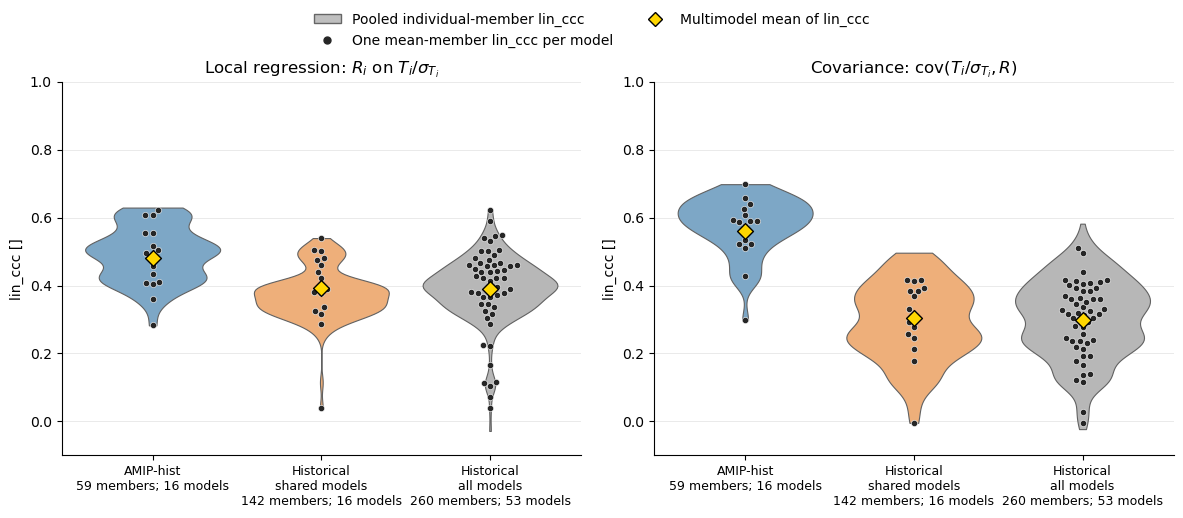

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                       # Requires seaborn >= 0.13
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Plot each member's RMSE, then overlay the average of those RMSEs for each model.
# This is NOT the RMSE of the ensemble-mean map.
plot_metrics = ["regTiRi", "covRTi"]
experiment_order = ["amip_hist", "historical_matched", "historical"]
experiment_labels = ["AMIP-hist", "Historical\nshared models", "Historical\nall models"]
colors = dict(zip(experiment_order, ["#74A9CF", "#FDAE6B", "#B7B7B7"]))
titles = [r"Local regression: $R_i$ on $T_i/\sigma_{T_i}$",
          r"Covariance: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$"]

# Convert the nested dictionaries into labeled tables, keeping model/member
# identities available for inspection. Exclude undefined scores from the plots.
member_rows, model_rows = [], []
for experiment in experiment_order:
    for metric in plot_metrics:
        for model, scores in member_scores[experiment][metric].items():
            for member, value in enumerate(scores["lin_ccc"]):
                if np.isfinite(value):
                    member_rows.append((experiment, metric, model, member, value))
            value = mean_member_scores[experiment][metric][model]["lin_ccc"]
            if np.isfinite(value):
                model_rows.append((experiment, metric, model, value))

violin_members = pd.DataFrame(member_rows, columns=["experiment", "metric", "model", "member", "value"])
violin_model_means = pd.DataFrame(model_rows, columns=["experiment", "metric", "model", "value"])

# Separate panel scales accommodate the different diagnostic magnitudes.
# Equal maximum violin widths emphasize shape; counts are shown beneath each.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, metric, title in zip(axes, plot_metrics, titles):
    members = violin_members[violin_members["metric"] == metric]
    means = violin_model_means[violin_model_means["metric"] == metric]

    # cut=0 limits the density to the observed range. bw_adjust controls smoothing.
    # Members are pooled without model reweighting, as intended for these violins.
    sns.violinplot(data=members, x="experiment", y="value", hue="experiment",
                   order=experiment_order, hue_order=experiment_order, palette=colors,
                   dodge=False, legend=False, inner=None, cut=0, density_norm="width",
                   bw_adjust=0.8, linewidth=0.8, saturation=0.8, ax=ax)

    # Each point represents one model. Beeswarm placement changes only horizontal
    # position, so its vertical position remains the model's mean member RMSE.
    sns.swarmplot(data=means, x="experiment", y="value", order=experiment_order,
                  color="0.15", size=4.5, edgecolor="white", linewidth=0.4, zorder=3, ax=ax)

    # Diamond: average of member/model RMSEs.
    ax.scatter(range(len(experiment_order)),
           [means.loc[means["experiment"] == exp, "value"].mean() for exp in experiment_order],
           marker="D", s=65, color="gold", edgecolor="black", zorder=5)

    # Report finite plotted counts rather than assuming a fixed ensemble size.
    tick_labels = []
    for experiment, label in zip(experiment_order, experiment_labels):
        n_members = (members["experiment"] == experiment).sum()
        n_models = (means["experiment"] == experiment).sum()
        tick_labels.append(f"{label}\n{n_members} members; {n_models} models")

    ax.set_xticks(range(len(experiment_order)))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set(title=title, xlabel="", ylabel=r"lin_ccc []", ylim=(0, None))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.6)
    ax.set_ylim([-0.1,1])
    sns.despine(ax=ax)

## Leif mods
# axes[1].set_ylim([0,1])

# One legend explains the two sampling levels across both panels.
handles = [Patch(facecolor="0.75", edgecolor="0.4", label="Pooled individual-member lin_ccc"),
           Line2D([], [], marker="o", linestyle="none", color="0.15", markersize=5,
                  label="One mean-member lin_ccc per model")]
handles.append(Line2D([], [], marker="D", linestyle="none", color="gold", markeredgecolor="black", markersize=7, label="Multimodel mean of lin_ccc"))
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig("./data/maps_2000_2014_covImp/Fig_1/member_lin_ccc_violins.png", dpi=300, bbox_inches="tight")
plt.show()